# Neural network classifier 2

___

## Data onboarding and preprocessing

### Load data

In [73]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.typing import NDArray

np.random.seed(42)

dir_path = "../training_data"

names, labels, samples = [], [], []
for label in range(10): 
    for file_path in [os.path.join(dir_path, f) for f in os.listdir(dir_path) if ".csv" in f and f"stroke_{label}" in f]: 
        names.append(os.path.splitext(os.path.basename(file_path))[0])
        labels.append(label)
        samples.append(pd.read_csv(file_path, header=None))

### Interpolate data

Define function to project 3d data to 2d

In [ ]:
def interpolate_data(points, target_length):
  #cumulative arc length
  diffs = np.diff(points, axis=0)
  segment_len = np.sqrt(np.sum(diffs**2, axis=1))
  cumlen = np.concatenate(([0], np.cumsum(segment_len)))
  total_len = cumlen[-1]
  # create target archs
  target_arc_len = np.linspace(0, total_len, target_length)
  # interpolate
  interpolated = np.zeros((target_length, points.shape[1]))
  for coord  in range(points.shape[1]):
    interpolated[:, coord] = np.interp(target_arc_len, cumlen, points[:, coord])
  # resample
  return interpolated

### Preprocess the data

Project the 3d samples to 2d, convert 2d data to images and flatten the images to 1d vectors

In [75]:
# Project 3D samples to 2D
max_len = max([len(s) for s in samples])
samples_interpolated = [interpolate_data(np.array(sample), max_len) for sample in samples]

# Stack the samples
samples_stacked = np.stack(samples_interpolated)

# Flatten the images to vectors for neural network classification
X_flat = np.array([s.flatten() for s in samples_stacked])

# Convert labels to a numpy array
y = np.array(labels)

___

## Training the model 

### Split data to training and test sets

In [76]:
from neural_network import *
from sklearn.model_selection import train_test_split

# One-hot encode y
y_encoded = one_hot_encode(y, np.arange(10))

# Split the data to training/validation and test sets
X_train, X_test, y_train, y_test = train_test_split(X_flat, y_encoded, test_size=0.20, stratify=y, random_state=42)

### Define model

In [77]:
from numpy.random import uniform

model = NeuralNetworkClassifier(
    Dense(uniform(-0.1, 0.1, size=(X_flat.shape[1], 512)), np.zeros(512), ReLU),
    Dense(uniform(-0.1, 0.1, size=(512, 256)), np.zeros(256), ReLU), 
    Dense(uniform(-0.1, 0.1, size=(256, 10)), np.zeros(10), Softmax)
)

### Train the model 

  3%|▎         | 304/10000 [00:20<10:57, 14.75it/s]

Model accuracy (training set): 20 %
Model accuracy (test set): 20 %


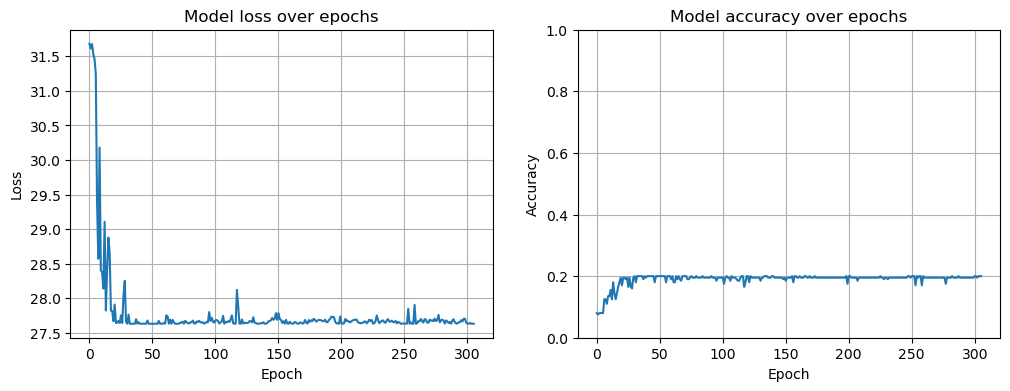

In [78]:
import matplotlib.pyplot as plt

# Training parameters
epochs, batch_size, learning_rate, tol, min_loss = 10000, 64, 0.0001, 1e-8, 1e-8
criterion = CategoricalCrossEntropySoftmax()

# Train the model  
loss_history, accuracy_history = train(model, X_train, y_train, X_val=X_test, y_val=y_test,
    criterion=criterion, max_iter=epochs, batch_size=batch_size, learning_rate=learning_rate, 
    tol=tol, min_loss=min_loss, verbose=True
)

# Visualize training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Model loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# Visualize validation accuracy
ax = plt.subplot(1, 2, 2)
ax.set_ylim([0, 1])
plt.grid()
plt.plot(accuracy_history)
plt.title("Model accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Measure accuracy
y_pred = model.forward(X_train)
print(f"Model accuracy (training set): {accuracy_score(np.argmax(y_train, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

# Measure accuracy
y_pred = model.forward(X_test)
print(f"Model accuracy (test set): {accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

Further training

  0%|          | 1/10000 [00:00<20:39,  8.07it/s]


Model accuracy (training set): 10 %
Model accuracy (test set): 10 %


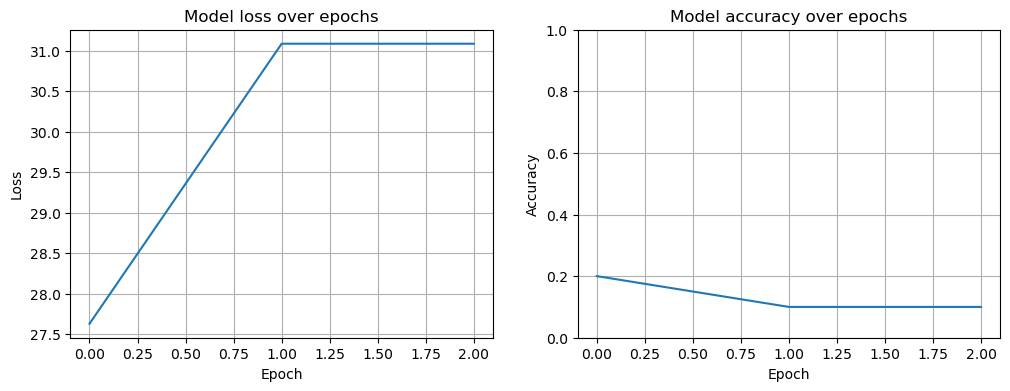

In [79]:
# Training parameters
epochs, batch_size, learning_rate, tol, min_loss = 10000, 64, 0.01, 1e-5, 1e-8
criterion = CategoricalCrossEntropySoftmax()

# Train the model  
loss_history, accuracy_history = train(model, X_train, y_train, X_val=X_test, y_val=y_test,
    criterion=criterion, max_iter=epochs, batch_size=batch_size, learning_rate=learning_rate, 
    tol=tol, min_loss=min_loss, verbose=True
)

# Visualize training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Model loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# Visualize validation accuracy
ax = plt.subplot(1, 2, 2)
ax.set_ylim([0, 1])
plt.grid()
plt.plot(accuracy_history)
plt.title("Model accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Measure accuracy
y_pred = model.forward(X_train)
print(f"Model accuracy (training set): {accuracy_score(np.argmax(y_train, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

# Measure accuracy
y_pred = model.forward(X_test)
print(f"Model accuracy (test set): {accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

___

## Combining the preprocessing pipeline and NN classifier to a single function

In [80]:
from typing import Callable

def preprocess(samples: list[NDArray|pd.DataFrame], image_size=image_size) -> tuple[NDArray, NDArray]: 
    samples_2d = [project_to_2d(sample) for sample in samples]
    images = [convert_to_image(sample, image_size) for sample in samples_2d]
    return np.array([image.flatten() for image in images])

def classify(samples: List[NDArray|pd.DataFrame], predict: Callable, preprocess: Callable) -> NDArray: 

    # Preprocess the samples
    X = preprocess(samples)
    
    # Predict the classes of the samples
    return predict(X)

NameError: name 'image_size' is not defined

In [ ]:
# Select random test set 
index = np.random.choice(len(samples), 100).astype(int)
test_datas, test_labels = [samples[i] for i in index], [labels[i] for i in index]

# Predict the test set using the classify-function
predicted_labels = classify(test_datas, model.predict, preprocess)

# Measure prediction accuracy
print(f"Classification accuracy: {accuracy_score(test_labels, predicted_labels)*100:.0f} %")

Classification accuracy: 95 %
